# EDA 05.03 — Spatial and Calendar Analysis

All calculations use `master_dataset_clean.parquet`. The source dataset is not modified.

In [1]:
# Import libraries
from pathlib import Path
import sys
from IPython.display import Image, display

In [2]:
# define the root directory of the project
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

CONFIG_PATH = PROJECT_ROOT / 'configs' / 'eda.yaml'
CONFIG_PATH

WindowsPath('e:/jcuenca/OneDrive - GUSCanada/5toTerm/01_Capstone/DataLocal/ontario-electricity-peak-risk/configs/eda.yaml')

In [3]:
# Import module to manage the EDA process
from src.ontario_peak_risk.eda.common import (
    load_eda_config,
    prepare_output_directories,
    load_clean_dataset,
)

In [4]:
# Config EDA process and Load the dataset
CONFIG, _ = load_eda_config(CONFIG_PATH)
REPORTS_DIR, FIGURES_DIR, DOCS_DIR = prepare_output_directories(CONFIG, PROJECT_ROOT)
dataset = load_clean_dataset(CONFIG, PROJECT_ROOT)
TARGET = CONFIG['columns']['target']

dataset.shape

(262944, 66)

In [5]:
# Import the function to run the spatial calendar analysis
from src.ontario_peak_risk.eda.spatial_calendar import run_spatial_calendar

In [6]:
# Generate the spatial and calendar analysis of the dataset and save the results in the output directories
results = run_spatial_calendar(
    dataset,
    TARGET,
    REPORTS_DIR,
    FIGURES_DIR,
    DOCS_DIR,
)

print("Spatial and calendar analysis completed.")

Spatial and calendar analysis completed.


In [7]:
# Show the results of the spatial and calendar analysis
results['spatial']

,fsa,hourly_mean,hourly_median,hourly_standard_deviation,hourly_minimum,hourly_maximum,p95,p975,p99
0,L4T,11617.975148,11179.00,3441.406039,5864.4,27796.6,18422.855,20880.4675,23120.932
1,M5R,7662.036624,7461.00,2019.435360,3721.5,16999.0,11308.500,12100.4425,13011.464
2,M5S,4108.749952,4044.75,986.417349,2060.4,7622.4,5862.010,6213.3125,6588.370
3,M6G,11488.117506,11243.00,3177.874939,4954.9,27460.1,16944.740,18290.2125,20200.372
4,M9R,5542.009675,5211.95,1899.714503,1377.7,16243.6,9242.840,10783.9425,12333.483
5,M9W,12337.413226,11916.35,4405.017340,4361.1,33712.2,19432.725,22068.3925,25710.637


In [8]:
# Display hourly demand profiles by FSA
results["hourly_by_fsa"].head(24)

,fsa,hour,mean,median,maximum
0,L4T,0,9475.024425,9241.60,20225.9
1,L4T,1,8699.170482,8489.00,18677.4
2,L4T,2,8199.027766,8028.30,17704.9
3,L4T,3,7996.981818,7831.75,17137.8
4,L4T,4,8097.008160,7950.30,16877.3
5,L4T,5,8379.681271,8246.65,16923.3
6,L4T,6,8943.253943,8758.15,17923.5
7,L4T,7,9772.102519,9528.95,19844.0
8,L4T,8,10684.661227,10293.00,21533.8
9,L4T,9,11615.360898,11059.80,22983.3


In [9]:
# Display mean hourly electricity consumption as a FSA × Hour matrix
results["hourly_by_fsa"].pivot(
    index="fsa",
    columns="hour",
    values="mean",
)

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
fsa,,,,,,,,,,,,,,,,,,,,,
L4T,9475.024425,8699.170482,8199.027766,7996.981818,8097.008160,8379.681271,8943.253943,9772.102519,10684.661227,11615.360898,...,13633.493538,13817.588499,14017.934173,14246.355093,14457.420372,14488.964458,14122.784173,13144.517141,11815.036254,10544.236418
M5R,6371.615991,5969.884830,5730.463253,5610.581873,5624.406462,5853.112486,6390.539485,7053.122180,7540.307010,7873.935433,...,8277.186637,8409.403122,8838.295345,9402.559693,9628.846440,9475.212924,9177.302848,8643.438554,7842.136966,7022.291073
M5S,3637.440416,3355.241128,3163.500164,3053.795947,3018.997043,3085.479244,3311.503614,3646.925794,3928.045674,4124.381982,...,4380.915827,4444.604929,4654.786090,4933.790854,5079.639321,5055.983899,4955.071632,4759.860186,4426.705422,4021.626342
M6G,9501.196276,8800.265170,8347.615827,8105.161829,8094.737404,8402.138116,9174.662870,10141.323932,10910.853176,11563.514841,...,12812.742059,13077.672015,13692.630778,14354.810186,14576.312651,14367.361993,13925.581161,13100.298412,11851.696166,10550.064841
M9R,4432.127054,4034.188116,3794.882202,3688.736802,3721.975246,3940.790800,4358.117470,4758.155915,5066.886309,5365.253395,...,6216.425027,6544.609419,7028.911610,7330.922618,7340.816101,7254.325685,7045.957448,6513.757338,5749.226506,5018.508762
M9W,9833.698631,9124.555696,8684.086035,8526.644359,8711.894031,9173.042935,9982.177766,10946.265498,11884.349452,12815.242935,...,14427.625685,14616.791512,14912.576396,15109.636473,15093.810296,14922.241457,14468.422344,13432.715663,12085.583242,10854.410186


In [10]:
# Display weekend effect
results["calendar_weekend"]

,is_weekend,count,mean,median,maximum
0,0,187776,8728.102632,8074.80,33712.2
1,1,75168,8954.129213,8197.35,31248.5


In [11]:
# Display holiday effect
results["calendar_holiday"]

,is_public_holiday,count,mean,median,maximum
0,0,255888,8797.360439,8111.05,33712.2
1,1,7056,8624.322095,8121.55,28494.6


In [12]:
# Display seasonal effect
results["calendar_season"]

,season,count,mean,median,maximum
0,Fall,65520,7797.693619,7135.75,29812.2
1,Spring,66240,7877.581005,7317.25,23875.9
2,Summer,66240,9952.128184,8951.85,33712.2
3,Winter,64944,9547.415650,9270.50,20741.6


In [13]:
# Display monthly effect
results["calendar_month"]

,month,month_name,count,mean,median,maximum
0,1,January,22320,9722.038163,9442.75,20741.6
1,2,February,20304,9559.227827,9361.85,20316.3
2,3,March,22320,8604.547527,8265.70,19194.4
3,4,April,21600,7677.193148,7225.30,17496.3
4,5,May,22320,7344.538217,6699.15,23875.9
5,6,June,21600,9103.121565,8131.40,33712.2
6,7,July,22320,10666.268535,9590.80,31498.5
7,8,August,22320,10059.607142,9151.90,32007.9
8,9,September,21600,7997.808463,7174.75,29812.2
9,10,October,22320,7261.917944,6681.60,22256.3


In [14]:
# Display quarterly effect
results["calendar_quarter"]

,quarter,count,mean,median,maximum
0,1,64944,9287.077396,8985.90,20741.6
1,2,65520,8033.957430,7261.15,33712.2
2,3,66240,9591.699998,8566.60,32007.9
3,4,66240,8259.558145,7704.00,22256.3


In [15]:
# Display workday effect
results["calendar_workday"]

,is_workday,count,mean,median,maximum
0,0,81360,8924.649270,8182.65,31248.5
1,1,181584,8733.603842,8076.55,33712.2


In [16]:
# Display long-weekend effect
results["calendar_long_weekend"]

,is_long_weekend,count,mean,median,maximum
0,0,251280,8805.318213,8118.65,33712.2
1,1,11664,8521.246914,7984.30,28494.6


In [17]:
# Display daylight-saving-time effect
results["calendar_dst"]

,is_daylight_saving_time,count,mean,median,maximum
0,0,91614,9220.943206,8879.05,20741.6
1,1,171330,8563.734861,7694.15,33712.2


In [18]:
# Display DST transition-day effect
results["calendar_dst_transition"]

,is_dst_transition_day,count,mean,median,maximum
0,0,261504,8794.114317,8112.3,33712.2
1,1,1440,8538.968264,7942.6,17902.7


In [19]:
# Display seasonal electricity-demand profiles by FSA
results["seasonal_by_fsa"]

,fsa,season,mean,median,maximum
0,L4T,Winter,11735.896960,11913.90,17348.1
1,L4T,Spring,10298.983687,10423.05,21973.1
2,L4T,Summer,14021.925353,13494.55,27796.6
3,L4T,Fall,10404.208645,10360.35,25114.0
4,M5R,Winter,9012.304056,8991.70,14814.8
5,M5R,Spring,6875.077600,6839.60,12716.3
6,M5R,Summer,8067.281558,7850.00,16999.0
7,M5R,Fall,6709.548425,6701.70,14484.0
8,M5S,Winter,4805.750148,4794.00,7622.4
9,M5S,Spring,3742.383705,3727.60,6602.1


Generated figures: 7

05_03_consumption_by_fsa.png


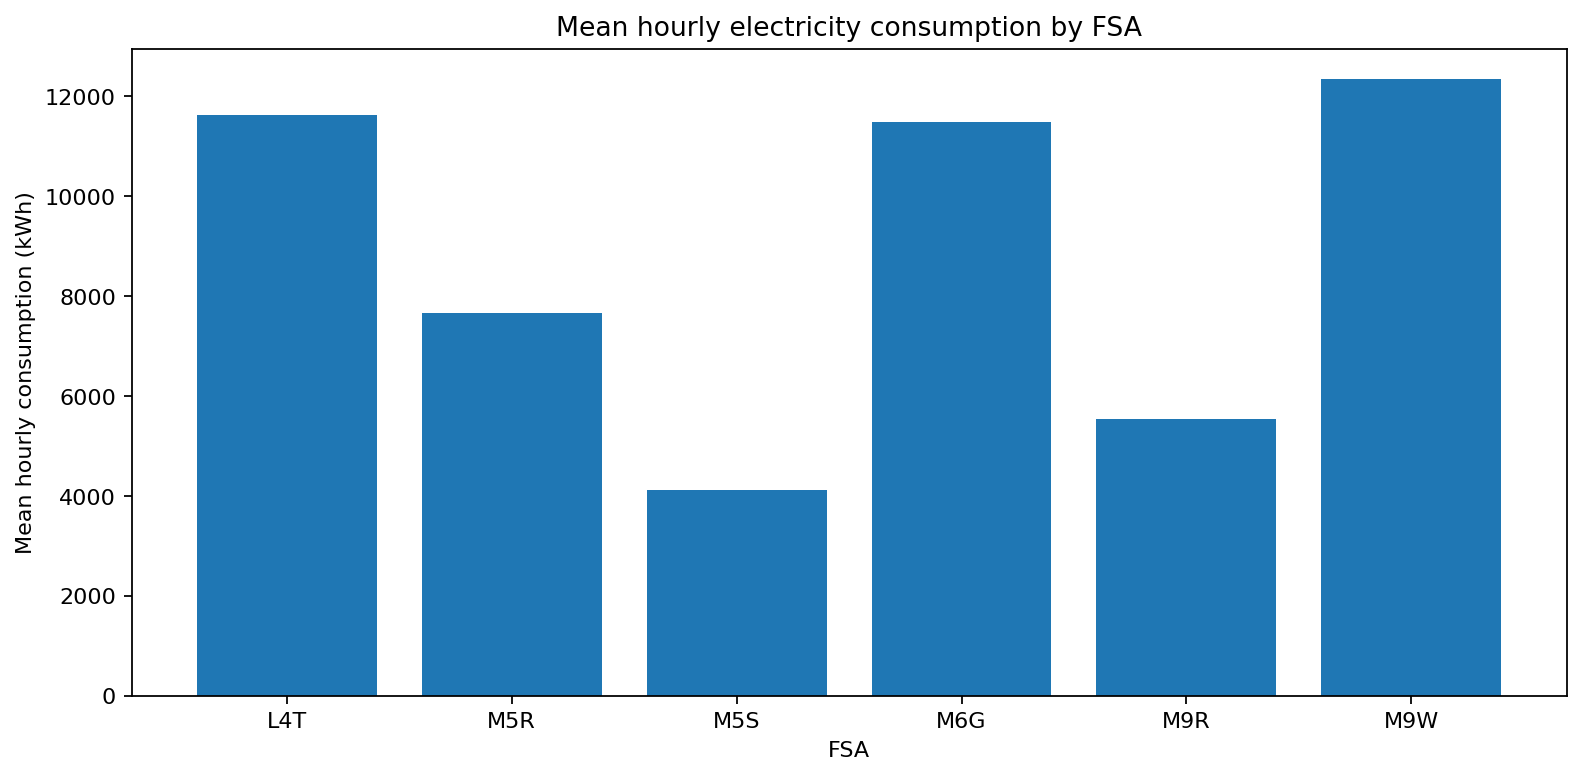


05_03_dst_transition_effect.png


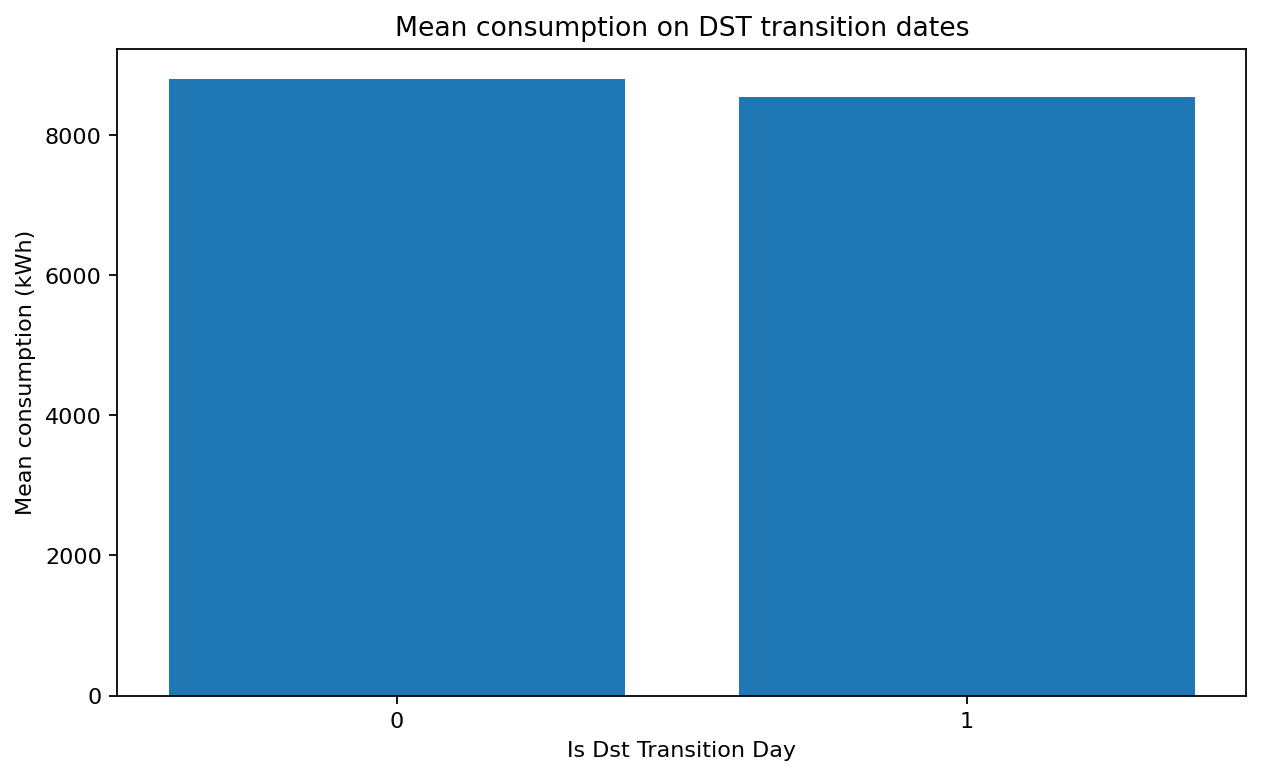


05_03_fsa_hour_heatmap.png


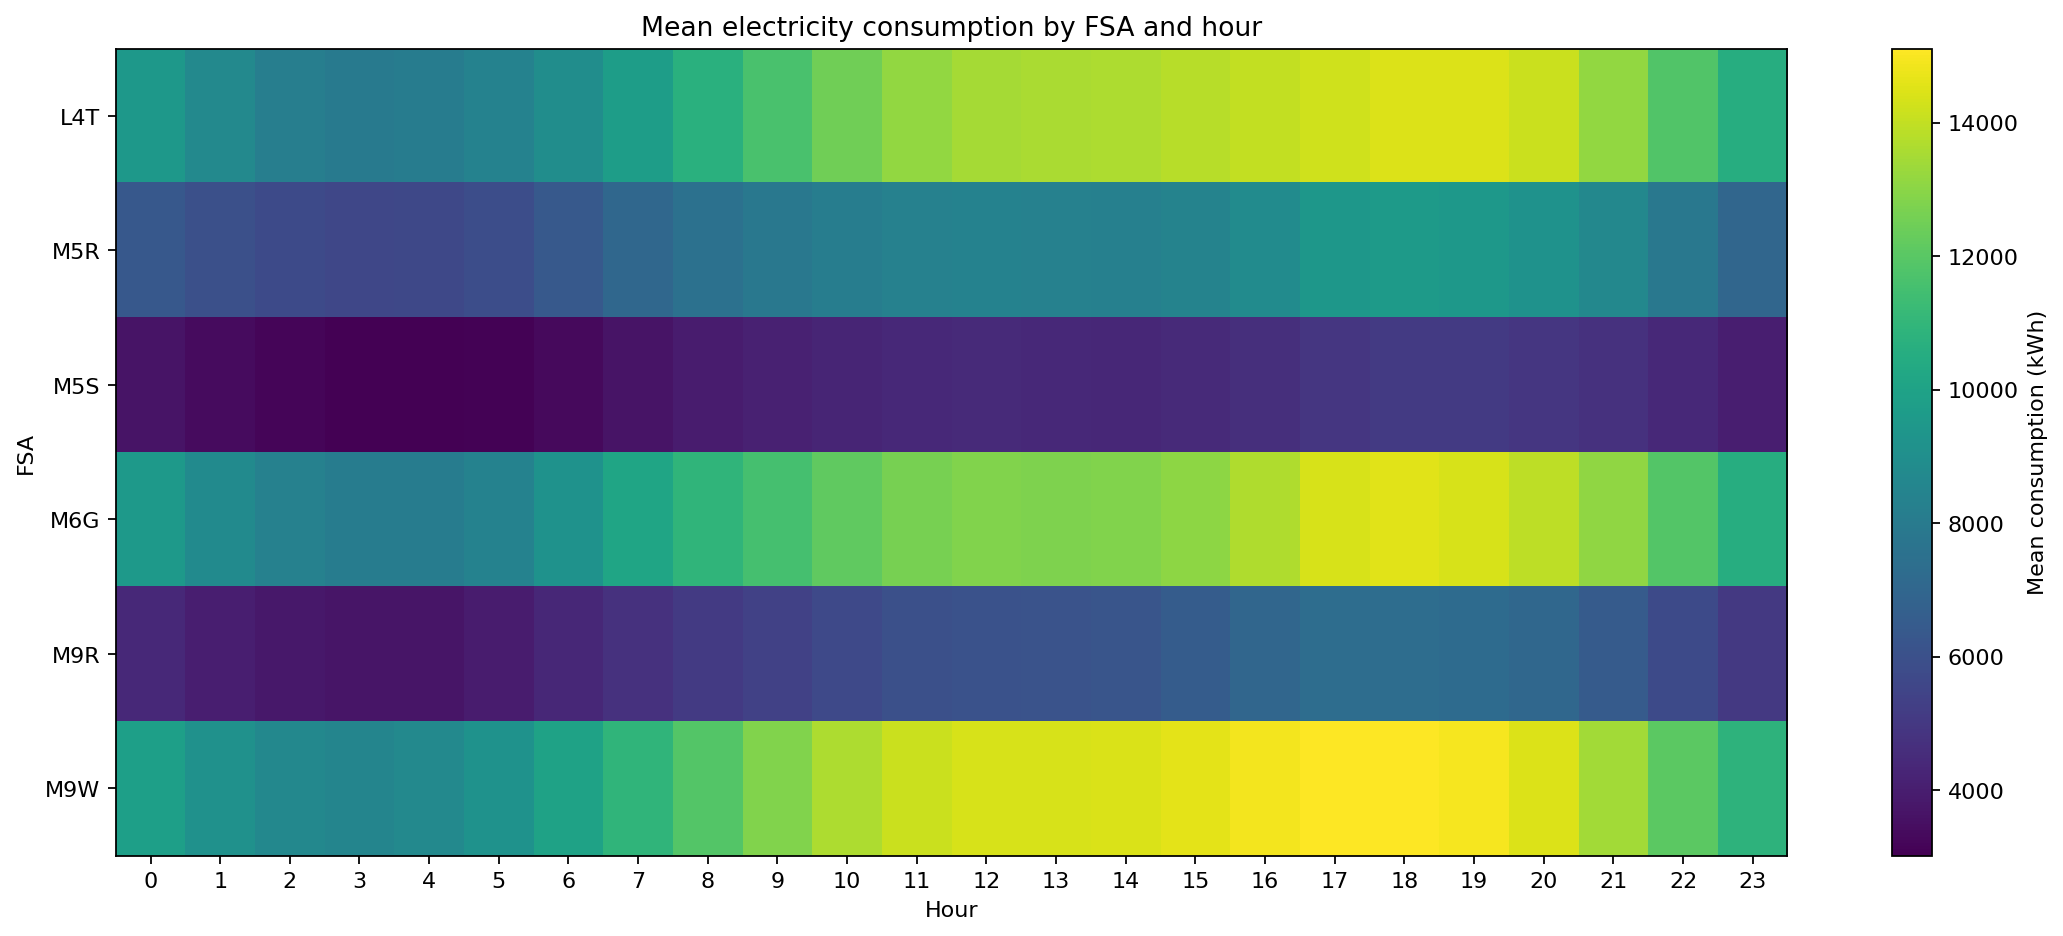


05_03_holiday_effect.png


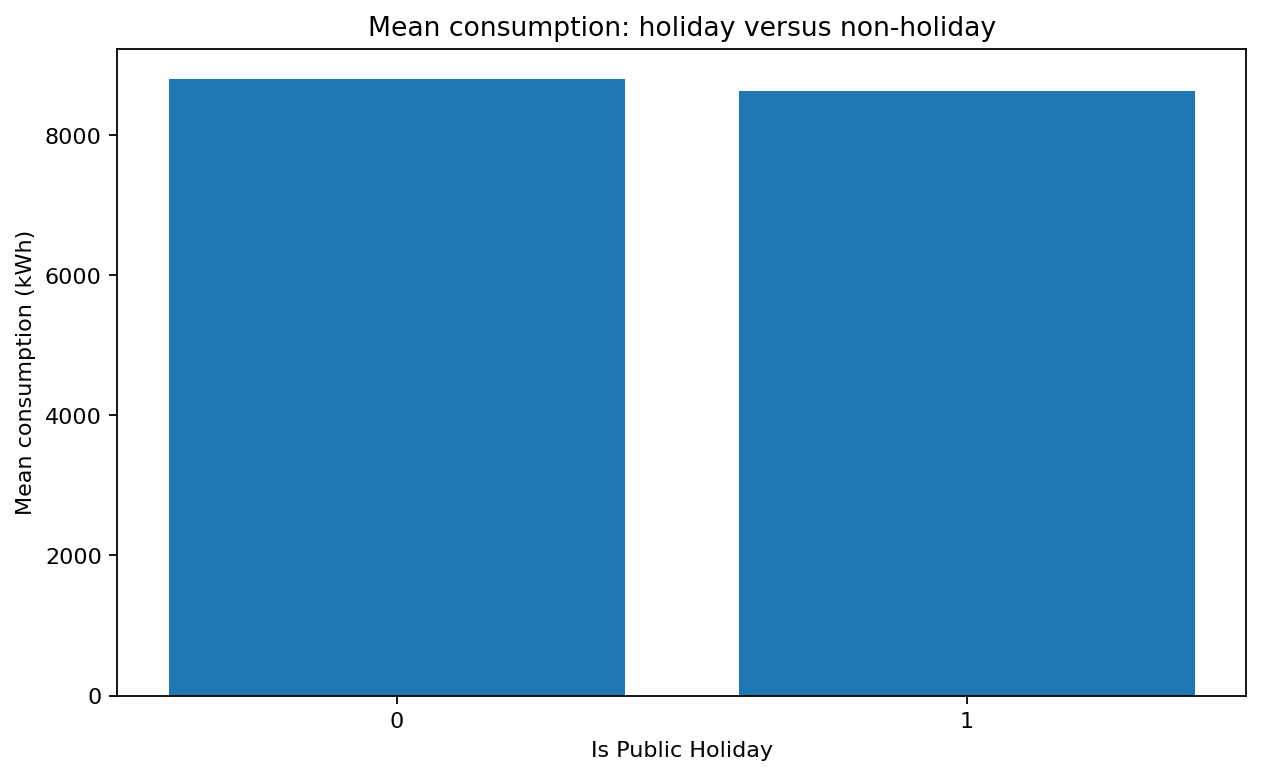


05_03_hourly_profiles_by_fsa.png


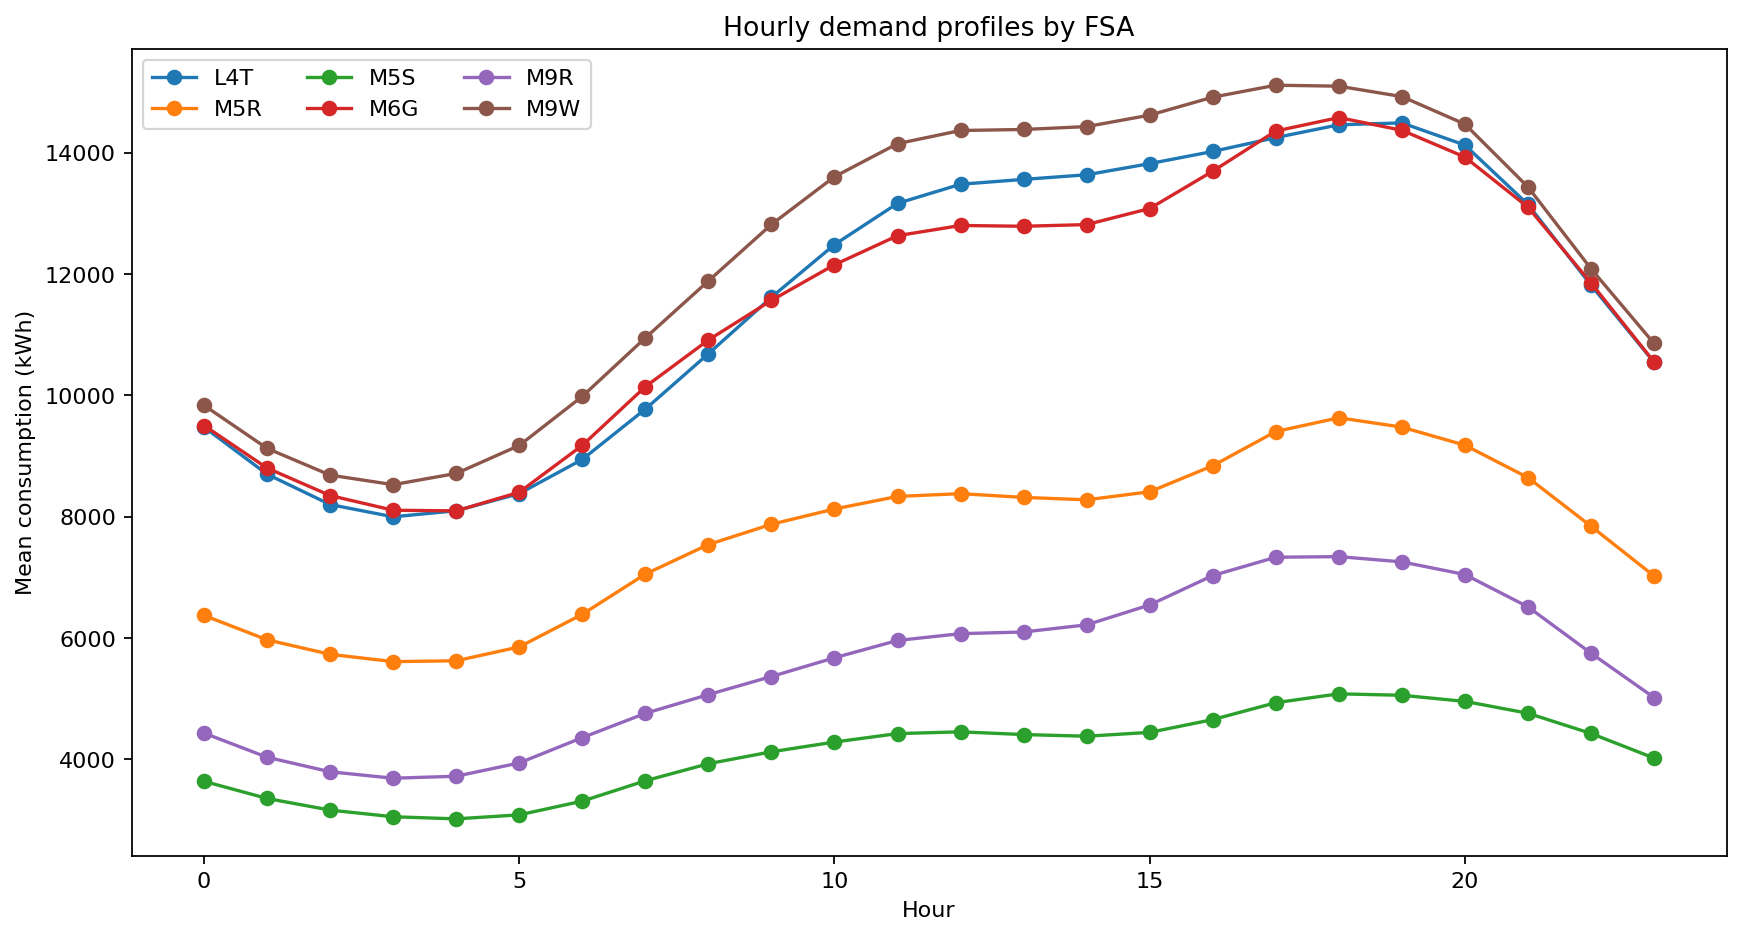


05_03_seasonal_profiles_by_fsa.png


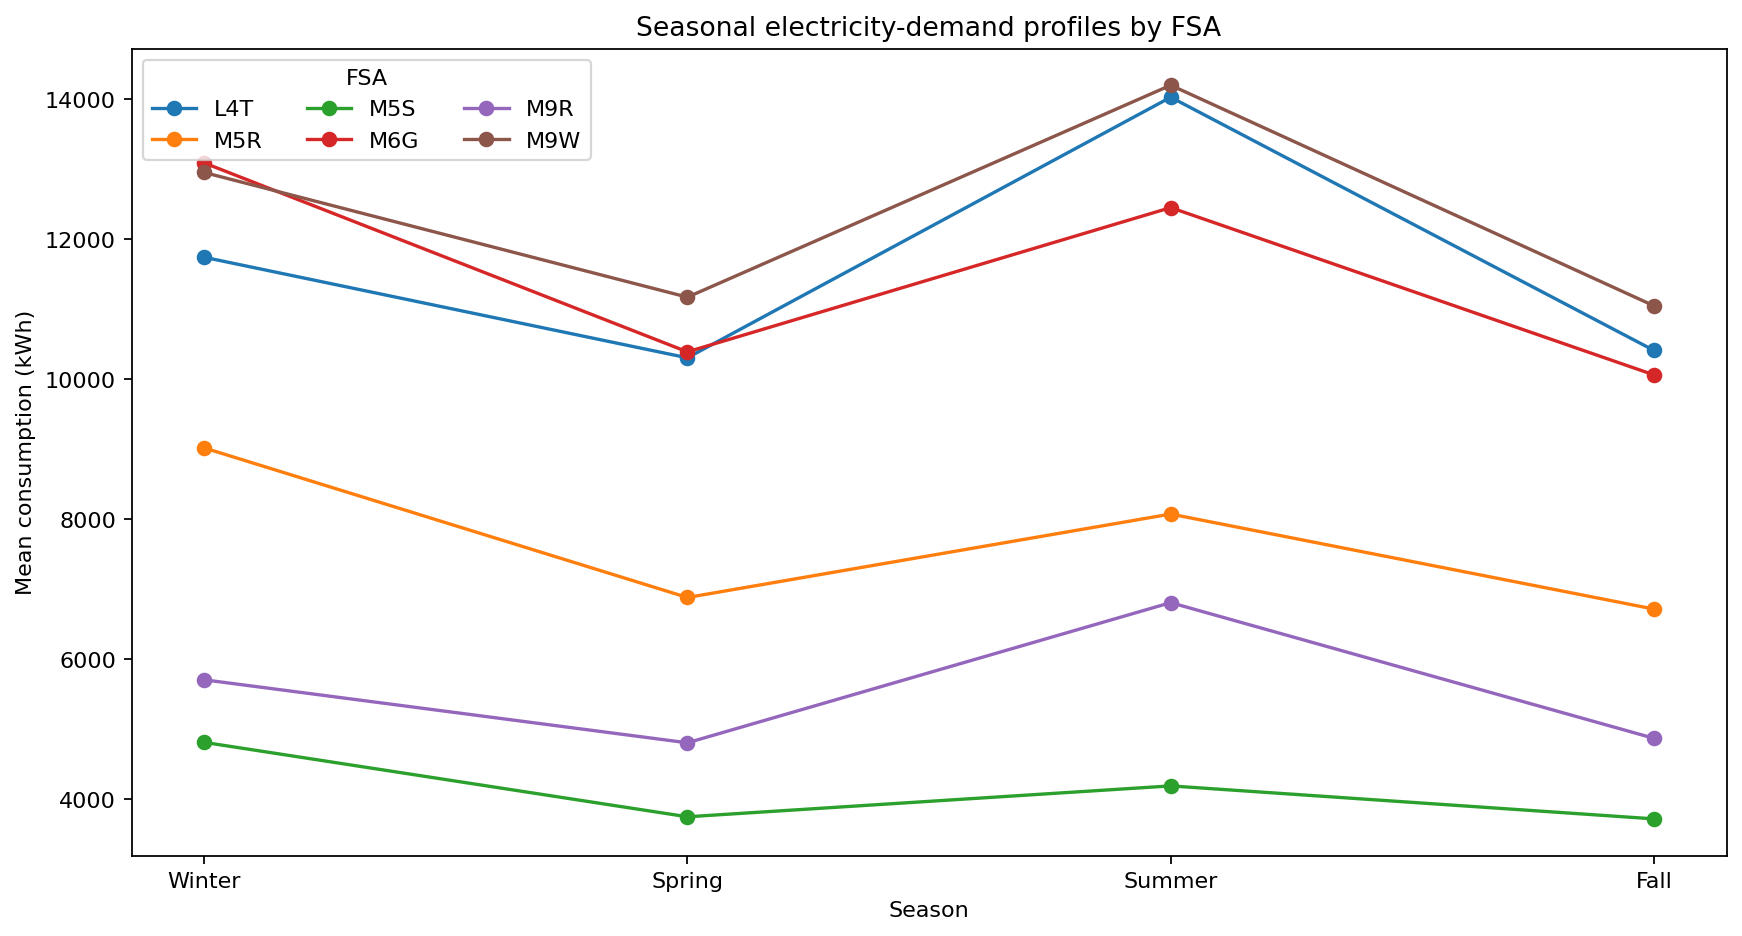


05_03_weekend_effect.png


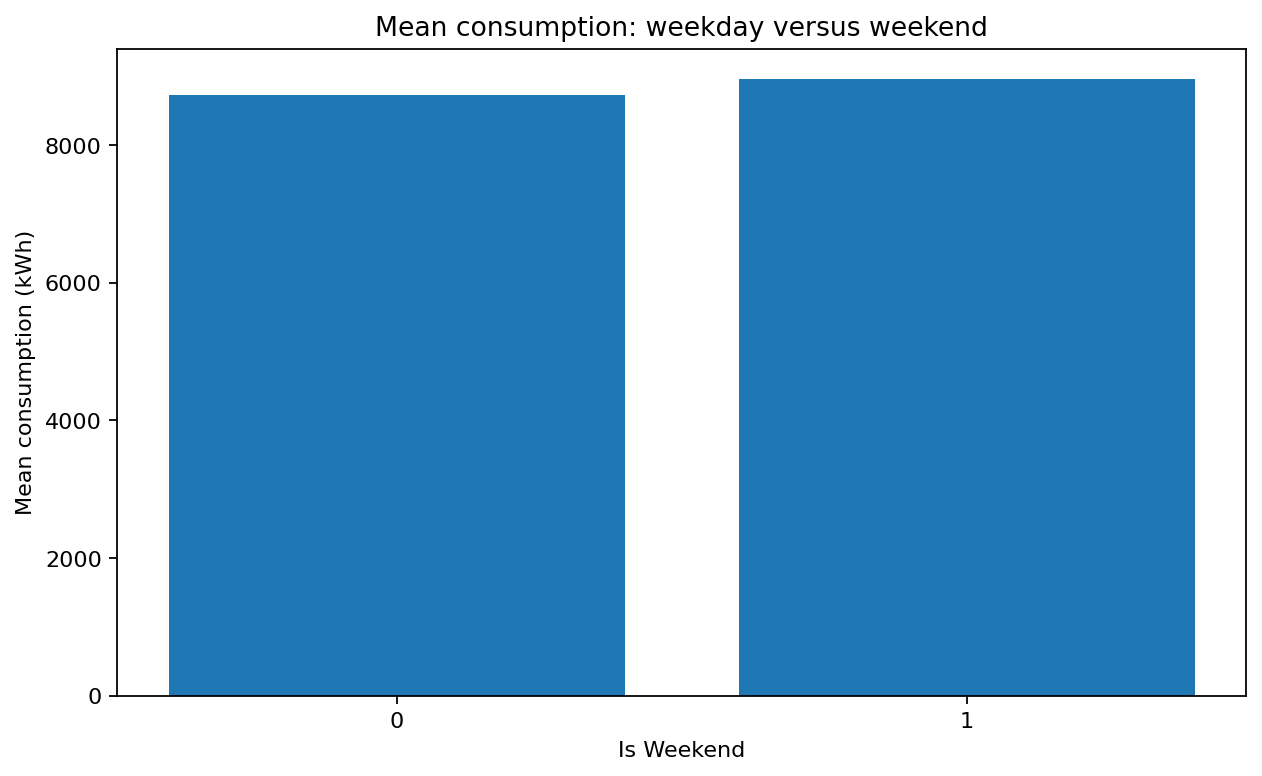

In [20]:
# Display all figures generated by the 05.03 analysis
generated_figures = sorted(
    FIGURES_DIR.glob("05_03_*.png")
)

print(
    f"Generated figures: {len(generated_figures)}"
)

for figure_path in generated_figures:
    print(f"\n{figure_path.name}")
    display(
        Image(
            filename=str(figure_path)
        )
    )

## Summary
Review the generated CSV tables, figures, and Markdown section report.

Review: 
- Report under `docs/eda/05_03_Spatial_and_Calendar_Analysis.md`.
- CSV reports under `reports/eda/`.